# Arquetipos de Early Game en League of Legends
## Proyecto Final — Modelación No Supervisada
### Diplomado Ciencias de Datos · Generación 33 · Abril 2026

**Pregunta central:** ¿Qué arquetipos de partida existen en LoL según el estilo de juego en los primeros 15 minutos — y qué implica cada uno para Riot Games, jugadores y analistas?

**Enfoque metodológico:**
1. PCA para reducir la dimensionalidad de las features de early game
2. KMeans para descubrir arquetipos de partida de forma no supervisada
3. Validación cruzando clusters con resultado (`blue_wins`) y duración

**Nota:** `blue_wins` y `game_duration` se usan **solo como validación externa**, nunca como features de entrada al modelo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
import pickle
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Carga y exploración de datos

In [ ]:
df = pd.read_csv('data/lol_matches_wide.csv')

# Convertir columnas numéricas que pueden quedar como string
numeric_cols = [c for c in df.columns if c not in [
    'match_id', 'processed_at',
    'blue_top_champion', 'blue_jungle_champion', 'blue_mid_champion', 'blue_adc_champion', 'blue_support_champion',
    'red_top_champion',  'red_jungle_champion',  'red_mid_champion',  'red_adc_champion',  'red_support_champion',
]]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

print(f"Shape: {df.shape}")
print(f"Partidas totales: {len(df)}")
print(f"Tipo de game_duration: {df['game_duration'].dtype}")

In [3]:
df.describe().round(2)

,game_duration,blue_num_tanks,blue_num_fighters,blue_num_mages,blue_num_marksmans,blue_num_controllers,red_num_tanks,red_num_fighters,red_num_mages,red_num_marksmans,...,first_blood_blue,first_tower_blue,first_dragon_blue,first_herald_blue,first_tower_time,first_dragon_time,first_herald_time,first_blood_time,blue_wins,processed_at
count,436.00,436.00,436.00,436.00,436.00,436.00,436.00,436.00,436.00,436.00,...,436.00,436.00,436.00,436.00,436.00,436.00,428.00,436.00,436.00,0.0
mean,32.31,0.63,1.69,1.07,1.11,0.50,0.61,1.78,1.06,1.10,...,0.52,0.51,0.45,0.54,852.09,474.06,999.10,130.38,0.53,NaN
std,6.47,0.72,0.84,0.74,0.45,0.53,0.70,0.80,0.78,0.48,...,0.50,0.50,0.50,0.50,106.93,130.53,71.17,59.31,0.50,NaN
min,15.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,592.09,324.24,918.43,38.48,0.00,NaN
25%,28.05,0.00,1.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,...,0.00,0.00,0.00,0.00,781.16,373.17,944.60,90.45,0.00,NaN
50%,32.12,1.00,2.00,1.00,1.00,0.00,0.00,2.00,1.00,1.00,...,1.00,1.00,0.00,1.00,852.63,436.42,980.64,120.96,1.00,NaN
75%,36.46,1.00,2.00,1.00,1.00,1.00,1.00,2.00,2.00,1.00,...,1.00,1.00,1.00,1.00,926.95,544.55,1029.80,155.09,1.00,NaN
max,52.95,3.00,4.00,4.00,3.00,2.00,3.00,4.00,3.00,3.00,...,1.00,1.00,1.00,1.00,1204.96,1046.80,1195.13,431.10,1.00,NaN


## 2. Análisis Exploratorio (EDA)

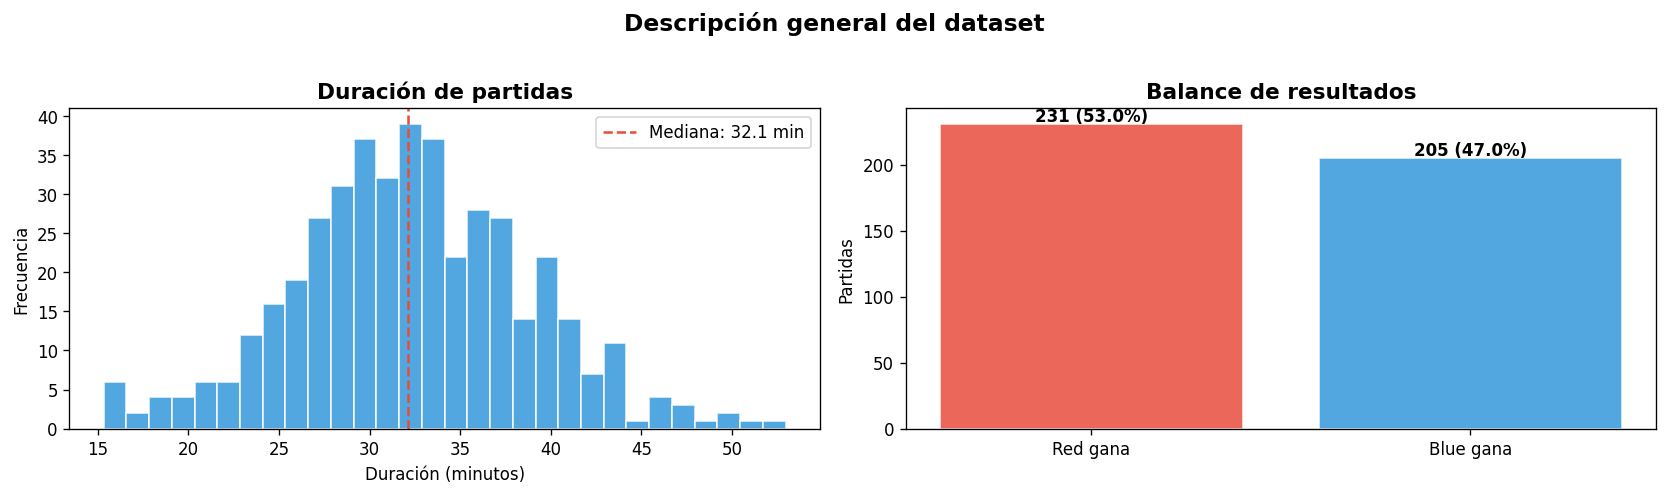

In [4]:
# Distribución de duración de partidas y balance de resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['game_duration'], bins=30, color='#3498DB', edgecolor='white', alpha=0.85)
axes[0].set_title('Duración de partidas', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Duración (minutos)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['game_duration'].median(), color='#E74C3C', linestyle='--', label=f"Mediana: {df['game_duration'].median():.1f} min")
axes[0].legend()

wins = df['blue_wins'].value_counts()
axes[1].bar(['Red gana', 'Blue gana'], wins.values, color=['#E74C3C', '#3498DB'], edgecolor='white', alpha=0.85)
axes[1].set_title('Balance de resultados', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Partidas')
for i, v in enumerate(wins.values):
    axes[1].text(i, v + 2, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

plt.suptitle('Descripción general del dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

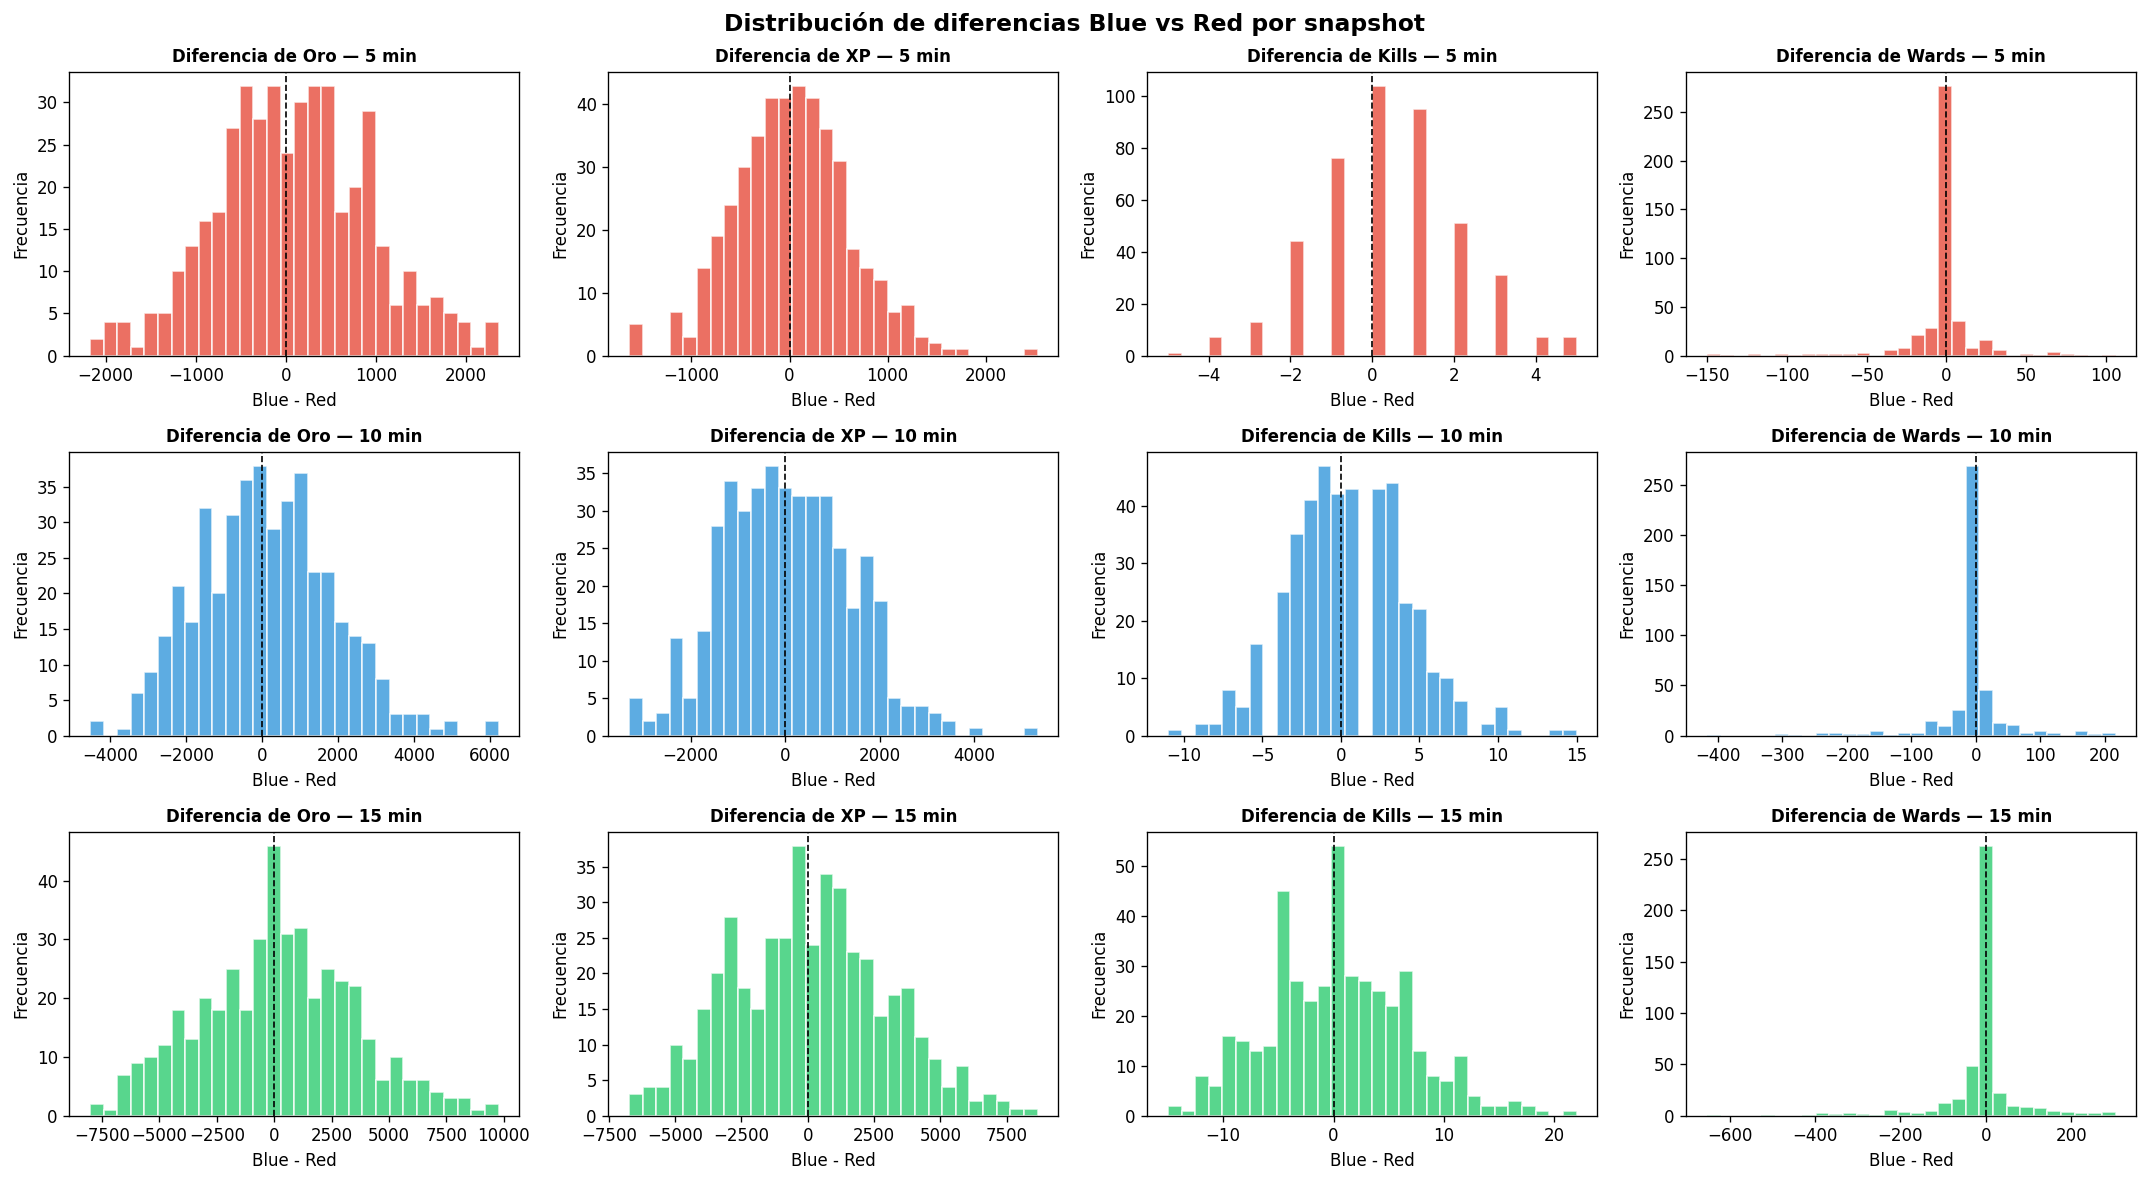

In [5]:
# Distribución de las diferencias clave en los 3 snapshots
diff_features = {
    5:  ['gold_diff_5',  'xp_diff_5',  'kills_diff_5',  'wards_placed_diff_5'],
    10: ['gold_diff_10', 'xp_diff_10', 'kills_diff_10', 'wards_placed_diff_10'],
    15: ['gold_diff_15', 'xp_diff_15', 'kills_diff_15', 'wards_placed_diff_15'],
}

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
labels = ['Diferencia de Oro', 'Diferencia de XP', 'Diferencia de Kills', 'Diferencia de Wards']

for row, (minute, feats) in enumerate(diff_features.items()):
    for col, feat in enumerate(feats):
        ax = axes[row][col]
        data = df[feat].dropna()
        ax.hist(data, bins=30, color=COLORS[row], edgecolor='white', alpha=0.8)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(f'{labels[col]} — {minute} min', fontsize=10, fontweight='bold')
        ax.set_xlabel('Blue - Red')
        ax.set_ylabel('Frecuencia')

plt.suptitle('Distribución de diferencias Blue vs Red por snapshot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

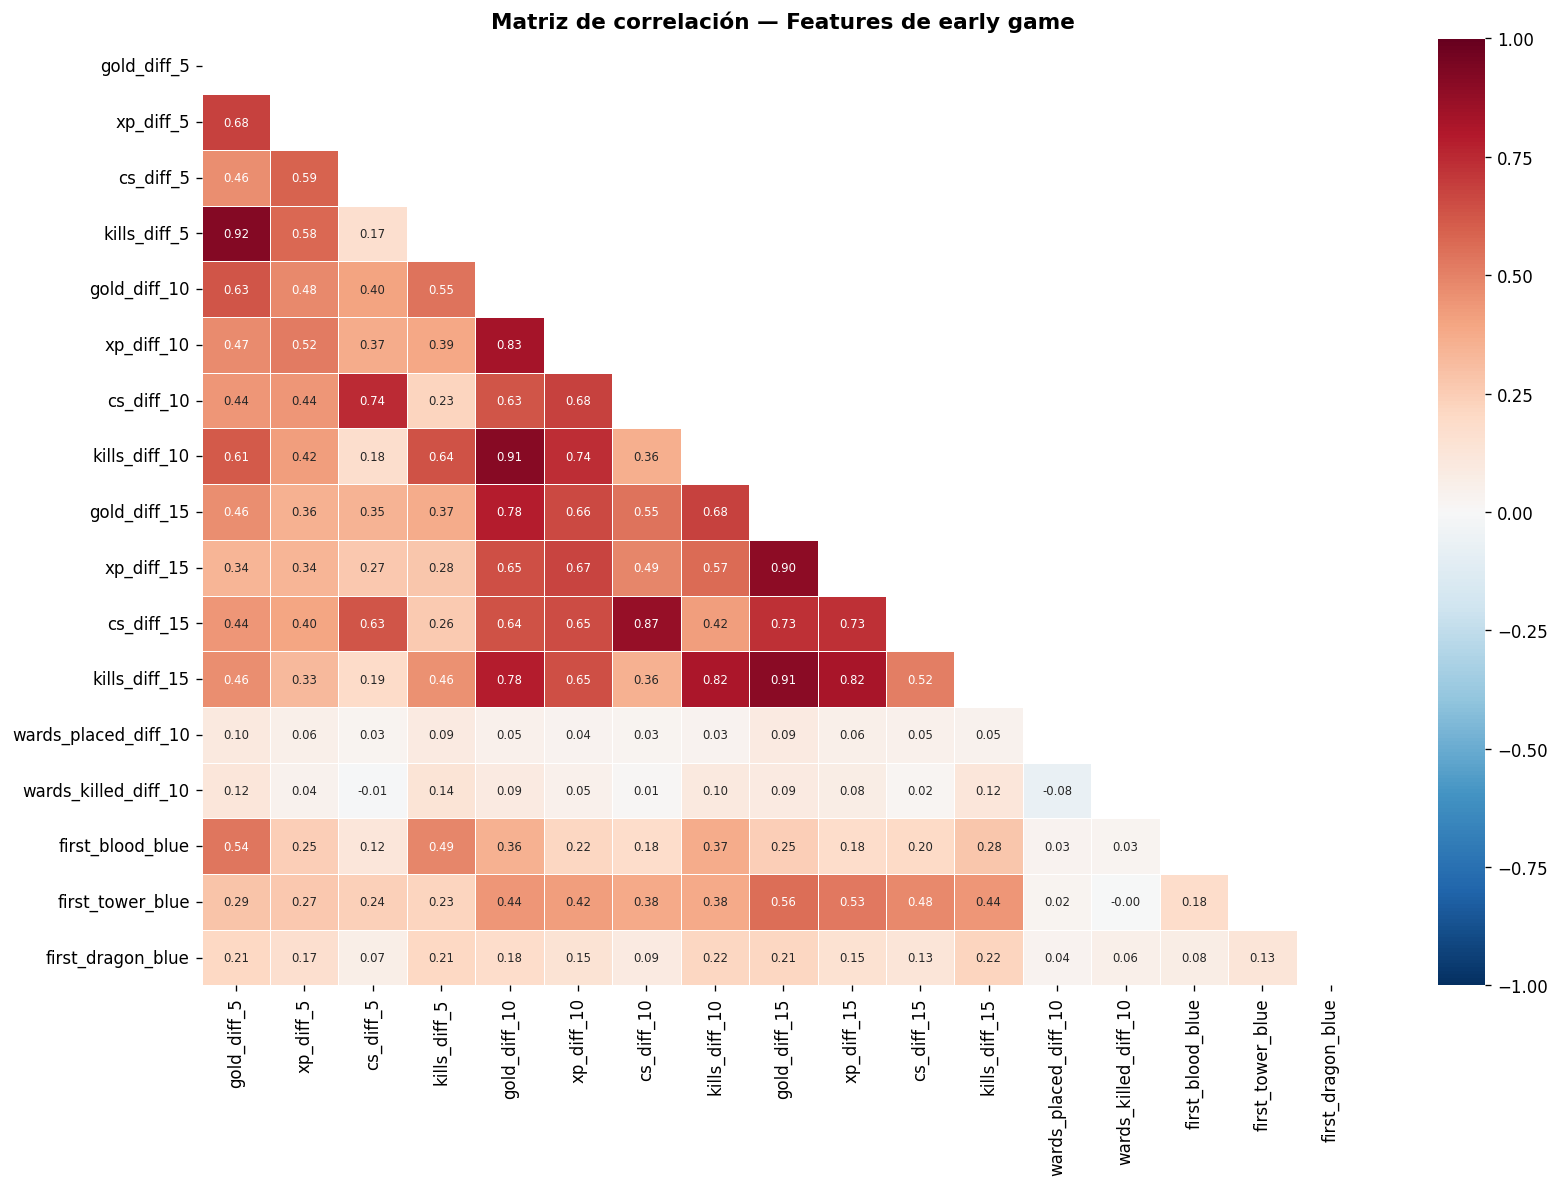

In [6]:
# Correlación entre features numéricas principales
numeric_cols = [
    'gold_diff_5', 'xp_diff_5', 'cs_diff_5', 'kills_diff_5',
    'gold_diff_10', 'xp_diff_10', 'cs_diff_10', 'kills_diff_10',
    'gold_diff_15', 'xp_diff_15', 'cs_diff_15', 'kills_diff_15',
    'wards_placed_diff_10', 'wards_killed_diff_10',
    'first_blood_blue', 'first_tower_blue', 'first_dragon_blue',
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 7}, linewidths=0.5)
ax.set_title('Matriz de correlación — Features de early game', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Preparación de features para clustering

In [7]:
# Features de entrada al modelo: diferencias de early game en los 3 snapshots
# Se excluyen: match_id, campeones (texto), targets (blue_wins), thresholds binarios
# (ya son derivados de las features continuas)
FEATURES = [
    # Diferencias 5 min
    'gold_diff_5', 'xp_diff_5', 'cs_diff_5', 'kills_diff_5',
    'dragon_diff_5', 'herald_diff_5', 'tower_diff_5',
    'wards_placed_diff_5', 'wards_killed_diff_5',
    # Diferencias 10 min
    'gold_diff_10', 'xp_diff_10', 'cs_diff_10', 'kills_diff_10',
    'dragon_diff_10', 'herald_diff_10', 'tower_diff_10',
    'wards_placed_diff_10', 'wards_killed_diff_10',
    # Diferencias 15 min
    'gold_diff_15', 'xp_diff_15', 'cs_diff_15', 'kills_diff_15',
    'dragon_diff_15', 'herald_diff_15', 'tower_diff_15',
    'wards_placed_diff_15', 'wards_killed_diff_15',
    # Primeros objetivos binarios
    'first_blood_blue', 'first_tower_blue', 'first_dragon_blue', 'first_herald_blue',
    # Tiempos de primeros objetivos
    'first_blood_time', 'first_tower_time', 'first_dragon_time', 'first_herald_time',
]

# Filtrar solo filas con datos completos en las features seleccionadas
df_model = df[FEATURES + ['blue_wins', 'game_duration']].dropna().copy()
df_model = df_model.reset_index(drop=True)

print(f"Partidas con datos completos: {len(df_model)} / {len(df)}")
print(f"Features de entrada: {len(FEATURES)}")

X = df_model[FEATURES].values
y = df_model['blue_wins'].values  # Solo para validación externa

Partidas con datos completos: 428 / 436
Features de entrada: 35


In [8]:
# Escalado estándar — necesario para PCA y KMeans (sensibles a magnitudes)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Escalado completado.")
print(f"Media post-escala (debe ser ~0): {X_scaled.mean():.4f}")
print(f"Std post-escala (debe ser ~1):   {X_scaled.std():.4f}")

Escalado completado.
Media post-escala (debe ser ~0): 0.0000
Std post-escala (debe ser ~1):   0.9103


## 4. PCA — Reducción dimensional

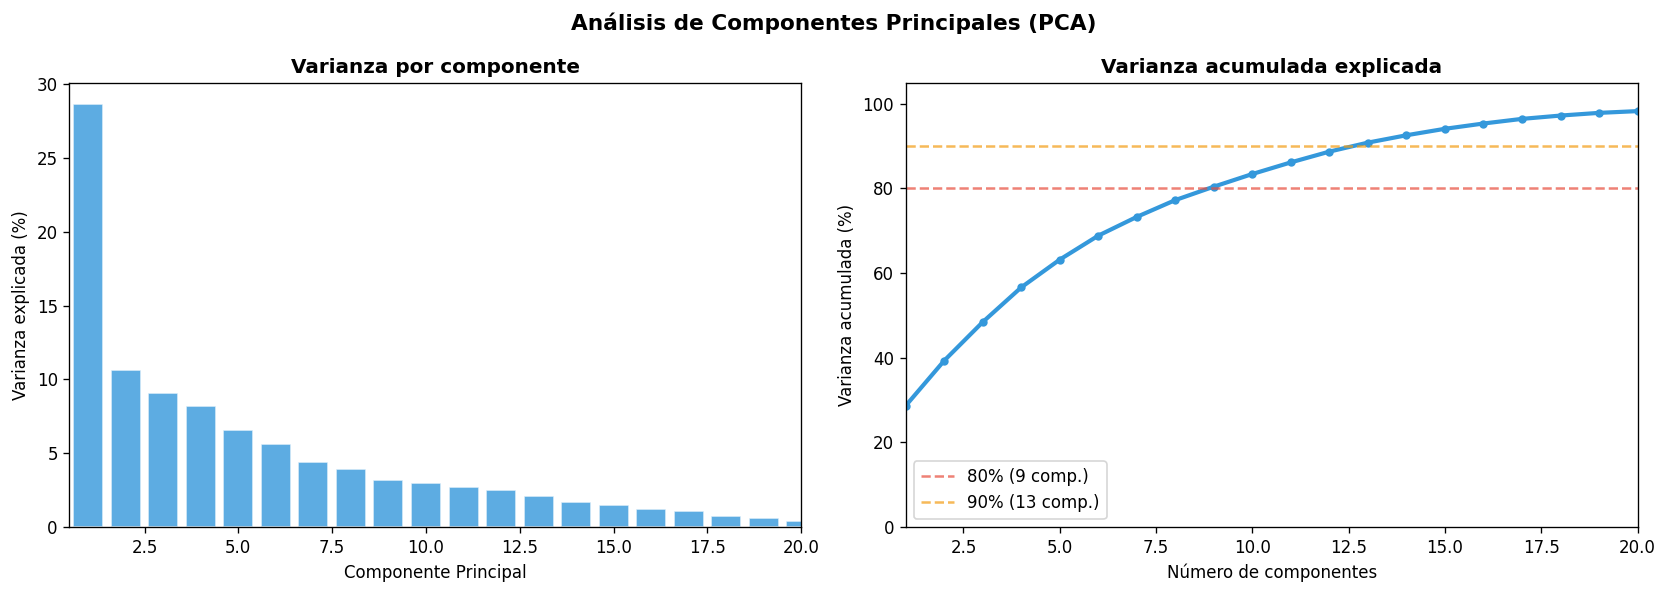

Componentes para explicar 80% de varianza: 9
Componentes para explicar 90% de varianza: 13


In [9]:
# PCA completo para ver cuántos componentes explican la varianza
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

varianza_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_componentes_80 = np.argmax(varianza_acum >= 0.80) + 1
n_componentes_90 = np.argmax(varianza_acum >= 0.90) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza explicada por componente
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_ * 100,
            color='#3498DB', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza por componente', fontsize=12, fontweight='bold')
axes[0].set_xlim(0.5, 20)

# Varianza acumulada
axes[1].plot(range(1, len(varianza_acum) + 1), varianza_acum * 100,
             color='#3498DB', linewidth=2.5, marker='o', markersize=4)
axes[1].axhline(80, color='#E74C3C', linestyle='--', alpha=0.7, label=f'80% ({n_componentes_80} comp.)')
axes[1].axhline(90, color='#F39C12', linestyle='--', alpha=0.7, label=f'90% ({n_componentes_90} comp.)')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada explicada', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].set_xlim(1, 20)
axes[1].set_ylim(0, 105)

plt.suptitle('Análisis de Componentes Principales (PCA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Componentes para explicar 80% de varianza: {n_componentes_80}")
print(f"Componentes para explicar 90% de varianza: {n_componentes_90}")

In [10]:
# Reducir a los componentes que explican ~80% de varianza
N_COMPONENTS = n_componentes_80

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Dimensiones originales: {X_scaled.shape}")
print(f"Dimensiones reducidas:  {X_pca.shape}")
print(f"Varianza total explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Dimensiones originales: (428, 35)
Dimensiones reducidas:  (428, 9)
Varianza total explicada: 80.4%


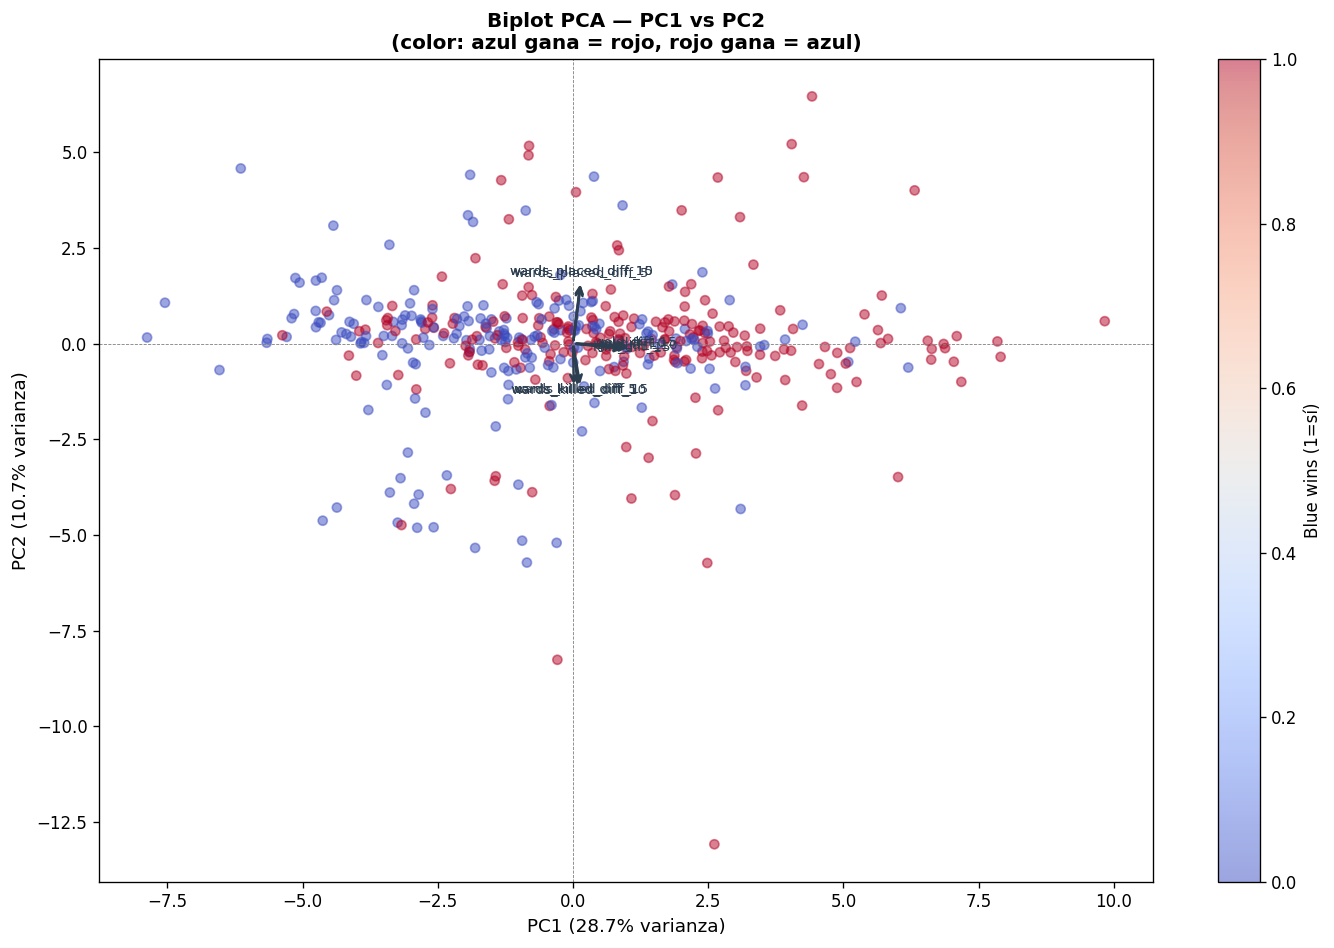

In [11]:
# Biplot PC1 vs PC2: ver qué features dominan cada componente
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter de partidas coloreado por resultado
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=y, cmap='coolwarm', alpha=0.5, s=30, zorder=2)

# Vectores de los loadings (top 10 features más influyentes en PC1 y PC2)
loadings = pca.components_[:2].T
loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
top_idx = np.argsort(loading_magnitudes)[-10:]

scale = 3.5
for i in top_idx:
    ax.annotate('', xy=(loadings[i, 0] * scale, loadings[i, 1] * scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.5))
    ax.text(loadings[i, 0] * scale * 1.1, loadings[i, 1] * scale * 1.1,
            FEATURES[i], fontsize=8, color='#2C3E50', ha='center')

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title('Biplot PCA — PC1 vs PC2\n(color: azul gana = rojo, rojo gana = azul)', fontsize=12, fontweight='bold')

plt.colorbar(scatter, ax=ax, label='Blue wins (1=sí)')
plt.tight_layout()
plt.show()

## 5. KMeans — Selección del número óptimo de clusters

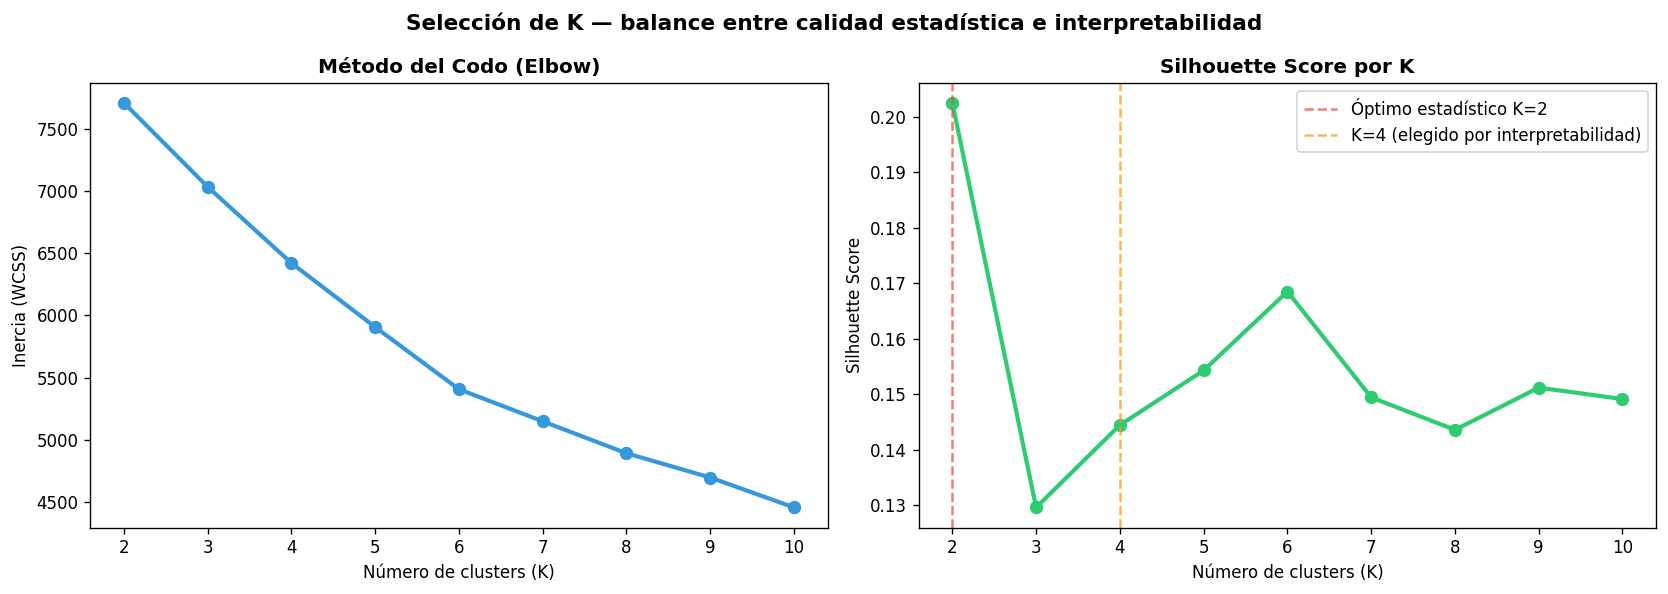

Óptimo estadístico: K=2 (Silhouette=0.2026)
K elegido: 4  — permite distinguir arquetipos con nombre e implicaciones de negocio
Silhouette con K=4: 0.1445


In [12]:
# Elbow + Silhouette para orientar la elección de K
K_RANGE = range(2, 11)
inertias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, lbl))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_RANGE, inertias, color='#3498DB', linewidth=2.5, marker='o', markersize=7)
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo (Elbow)', fontsize=12, fontweight='bold')
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(K_RANGE, silhouettes, color='#2ECC71', linewidth=2.5, marker='o', markersize=7)
best_k_auto = list(K_RANGE)[np.argmax(silhouettes)]
axes[1].axvline(best_k_auto, color='#E74C3C', linestyle='--', alpha=0.7, label=f'Óptimo estadístico K={best_k_auto}')
axes[1].axvline(4, color='#F39C12', linestyle='--', alpha=0.7, label='K=4 (elegido por interpretabilidad)')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K', fontsize=12, fontweight='bold')
axes[1].set_xticks(list(K_RANGE))
axes[1].legend()

plt.suptitle('Selección de K — balance entre calidad estadística e interpretabilidad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Óptimo estadístico: K={best_k_auto} (Silhouette={max(silhouettes):.4f})")
print(f"K elegido: 4  — permite distinguir arquetipos con nombre e implicaciones de negocio")
print(f"Silhouette con K=4: {silhouettes[2]:.4f}")

## 6. KMeans con K=4 — Los 4 arquetipos de partida

In [13]:
K_FINAL = 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_pca)
df_model['cluster'] = cluster_labels

KEY_FEATURES_PROFILE = [
    'gold_diff_5', 'gold_diff_10', 'gold_diff_15',
    'kills_diff_5', 'kills_diff_10', 'kills_diff_15',
    'xp_diff_10', 'cs_diff_10',
    'dragon_diff_10', 'herald_diff_10', 'tower_diff_10',
    'wards_placed_diff_10', 'wards_killed_diff_10',
    'first_blood_blue', 'first_tower_blue', 'first_dragon_blue',
    'game_duration',
]
profiles = df_model.groupby('cluster')[KEY_FEATURES_PROFILE + ['blue_wins']].mean()

# Etiquetado basado en gold_diff_15 y kills_diff_10 como ejes principales
# Cada cluster recibe el nombre del patrón que mejor lo describe
def assign_archetype(c, row):
    gold15  = row['gold_diff_15']
    kills10 = row['kills_diff_10']

    if gold15 > 1500 and kills10 > 1:
        return 'Snowball Temprano'        # Blue domina en todo
    elif gold15 < -1500 and kills10 < -1:
        return 'Remontada / Red domina'  # Red domina en todo
    elif gold15 >= 0 and abs(kills10) <= 0.5:
        return 'Control de Objetivos'    # Blue con ventaja de oro sin kills: visión/objetivos
    else:
        return 'Partida Equilibrada'     # Ningún equipo consolida ventaja clara

archetype_map = {c: assign_archetype(c, profiles.loc[c]) for c in range(K_FINAL)}
df_model['archetype'] = df_model['cluster'].map(archetype_map)

ARCHETYPE_COLORS = {
    'Snowball Temprano':      '#E74C3C',
    'Remontada / Red domina': '#3498DB',
    'Control de Objetivos':   '#2ECC71',
    'Partida Equilibrada':    '#95A5A6',
}

print(f"KMeans K={K_FINAL} — Silhouette: {silhouette_score(X_pca, cluster_labels):.4f}\n")
print("Arquetipos asignados:")
for c, name in archetype_map.items():
    n = (cluster_labels == c).sum()
    wr = profiles.loc[c, 'blue_wins'] * 100
    gold = profiles.loc[c, 'gold_diff_15']
    kills = profiles.loc[c, 'kills_diff_10']
    print(f"  Cluster {c} → '{name}'  (n={n}, Blue WR={wr:.0f}%, gold@15={gold:.0f}, kills@10={kills:.1f})")

print()
print("Distribución de arquetipos:")
print(df_model['archetype'].value_counts())

KMeans K=4 — Silhouette: 0.1445

Arquetipos asignados:
  Cluster 0 → 'Control de Objetivos'  (n=188, Blue WR=52%, gold@15=256, kills@10=0.1)
  Cluster 1 → 'Snowball Temprano'  (n=117, Blue WR=76%, gold@15=3465, kills@10=4.2)
  Cluster 2 → 'Partida Equilibrada'  (n=19, Blue WR=53%, gold@15=-867, kills@10=0.0)
  Cluster 3 → 'Remontada / Red domina'  (n=104, Blue WR=27%, gold@15=-3722, kills@10=-3.1)

Distribución de arquetipos:
archetype
Control de Objetivos      188
Snowball Temprano         117
Remontada / Red domina    104
Partida Equilibrada        19
Name: count, dtype: int64


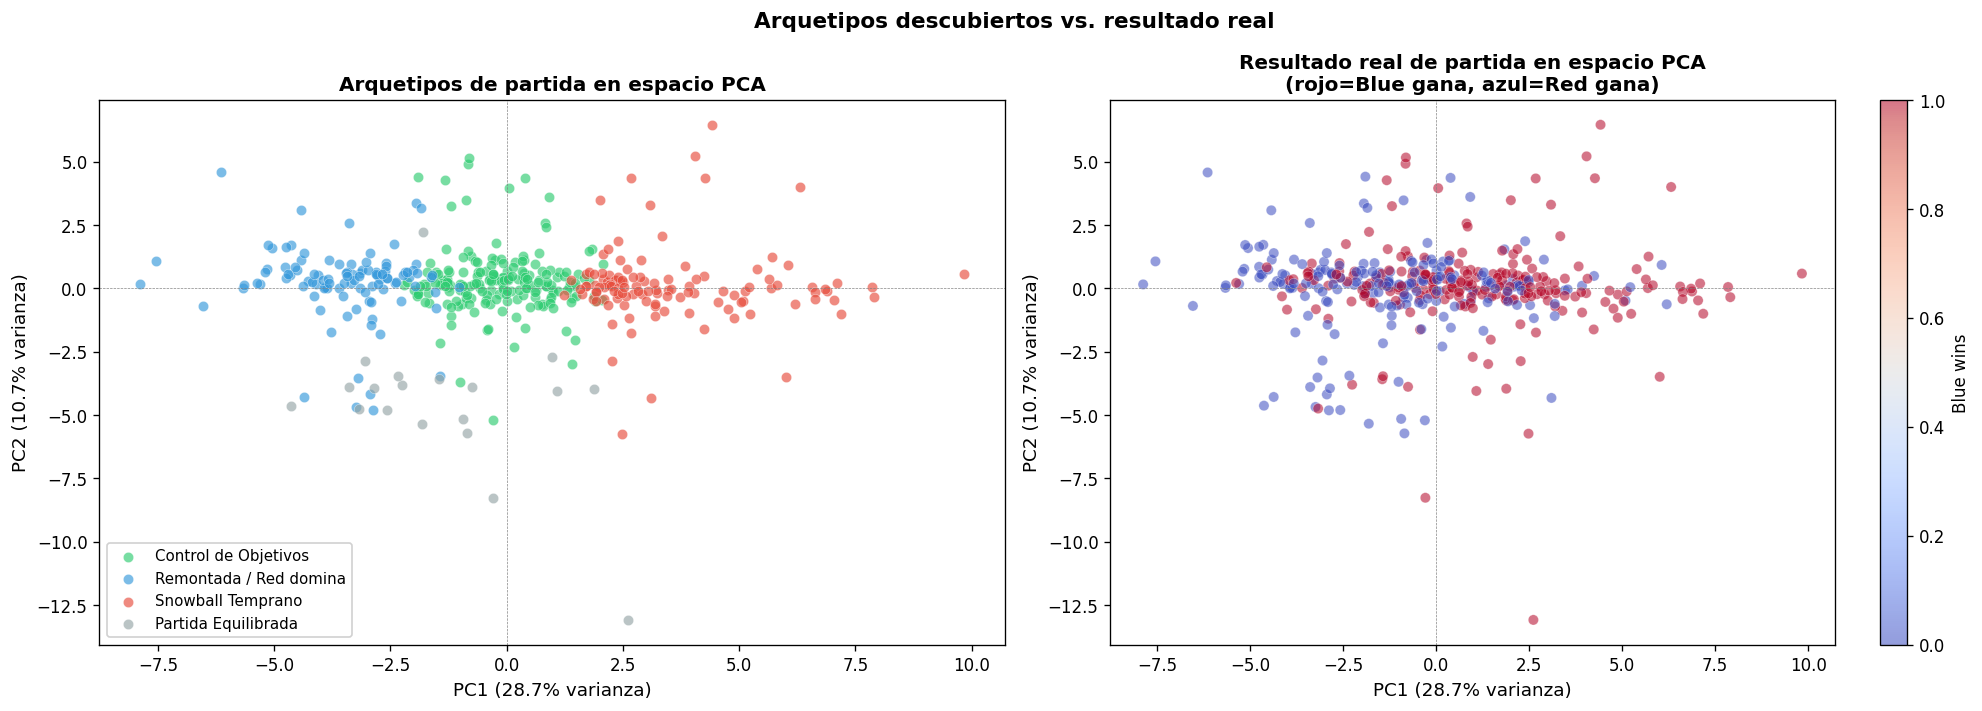

In [14]:
# Visualización PCA coloreada por arquetipo con nombres reales
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

archetypes_present = df_model['archetype'].unique()

for arch in archetypes_present:
    mask = df_model['archetype'] == arch
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=ARCHETYPE_COLORS.get(arch, '#7F8C8D'),
                    label=arch, alpha=0.65, s=38,
                    edgecolors='white', linewidths=0.3)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=11)
axes[0].set_title('Arquetipos de partida en espacio PCA', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9, framealpha=0.9)
axes[0].axhline(0, color='grey', linewidth=0.4, linestyle='--')
axes[0].axvline(0, color='grey', linewidth=0.4, linestyle='--')

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=y, cmap='coolwarm', alpha=0.55, s=38,
                           edgecolors='white', linewidths=0.3)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=11)
axes[1].set_title('Resultado real de partida en espacio PCA\n(rojo=Blue gana, azul=Red gana)', fontsize=12, fontweight='bold')
axes[1].axhline(0, color='grey', linewidth=0.4, linestyle='--')
axes[1].axvline(0, color='grey', linewidth=0.4, linestyle='--')
plt.colorbar(scatter2, ax=axes[1], label='Blue wins')

plt.suptitle('Arquetipos descubiertos vs. resultado real', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Perfil de cada arquetipo — ¿Qué caracteriza a cada uno?

In [15]:
cluster_profiles = df_model.groupby('archetype')[KEY_FEATURES_PROFILE + ['blue_wins']].mean().round(2)
print("Perfil medio por arquetipo:")
cluster_profiles

Perfil medio por arquetipo:


,gold_diff_5,gold_diff_10,gold_diff_15,kills_diff_5,kills_diff_10,kills_diff_15,xp_diff_10,cs_diff_10,dragon_diff_10,herald_diff_10,tower_diff_10,wards_placed_diff_10,wards_killed_diff_10,first_blood_blue,first_tower_blue,first_dragon_blue,game_duration,blue_wins
archetype,,,,,,,,,,,,,,,,,,
Control de Objetivos,44.49,7.50,256.41,0.18,0.13,0.20,-123.97,-2.85,-0.25,0.0,0.0,6.44,0.00,0.51,0.52,0.34,33.99,0.52
Partida Equilibrada,-234.00,-283.58,-866.84,-0.16,0.00,-0.53,-45.21,-8.68,-0.47,0.0,0.0,-217.79,-0.79,0.47,0.53,0.37,31.17,0.53
Remontada / Red domina,-629.32,-1799.33,-3722.40,-0.95,-3.06,-5.95,-1280.77,-28.62,-0.21,0.0,0.0,-3.62,-0.03,0.25,0.11,0.36,31.35,0.27
Snowball Temprano,819.32,2019.09,3465.07,1.50,4.15,6.34,1479.49,25.38,0.32,0.0,0.0,4.67,0.22,0.77,0.85,0.73,31.57,0.76


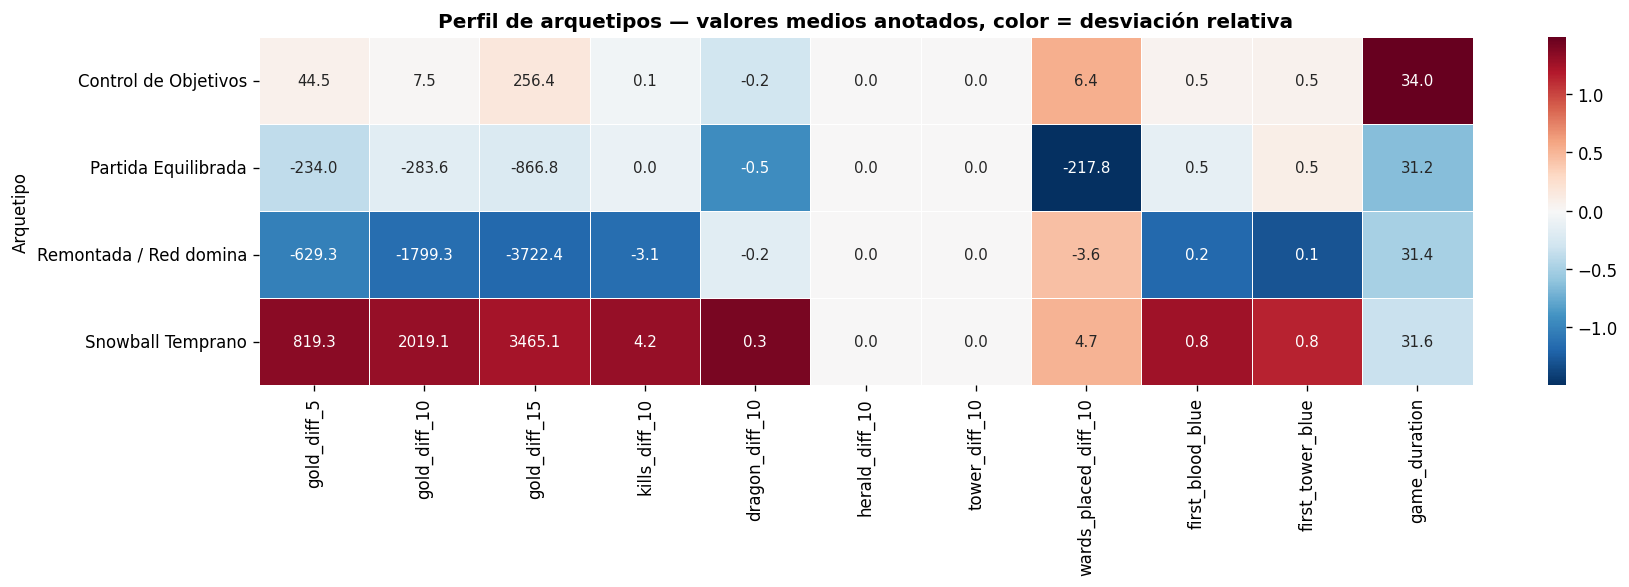

In [16]:
# Heatmap de perfiles — qué dimensiones distinguen a cada arquetipo
DISPLAY_FEATURES = [
    'gold_diff_5', 'gold_diff_10', 'gold_diff_15',
    'kills_diff_10', 'dragon_diff_10', 'herald_diff_10',
    'tower_diff_10', 'wards_placed_diff_10',
    'first_blood_blue', 'first_tower_blue', 'game_duration',
]

profile_norm = cluster_profiles[DISPLAY_FEATURES].apply(
    lambda col: (col - col.mean()) / (col.std() + 1e-8)
)

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(profile_norm,
            annot=cluster_profiles[DISPLAY_FEATURES],
            fmt='.1f', cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.6, annot_kws={'size': 9})
ax.set_title('Perfil de arquetipos — valores medios anotados, color = desviación relativa',
             fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Arquetipo')
plt.tight_layout()
plt.show()

## 8. Validación externa — Win rate y duración por arquetipo

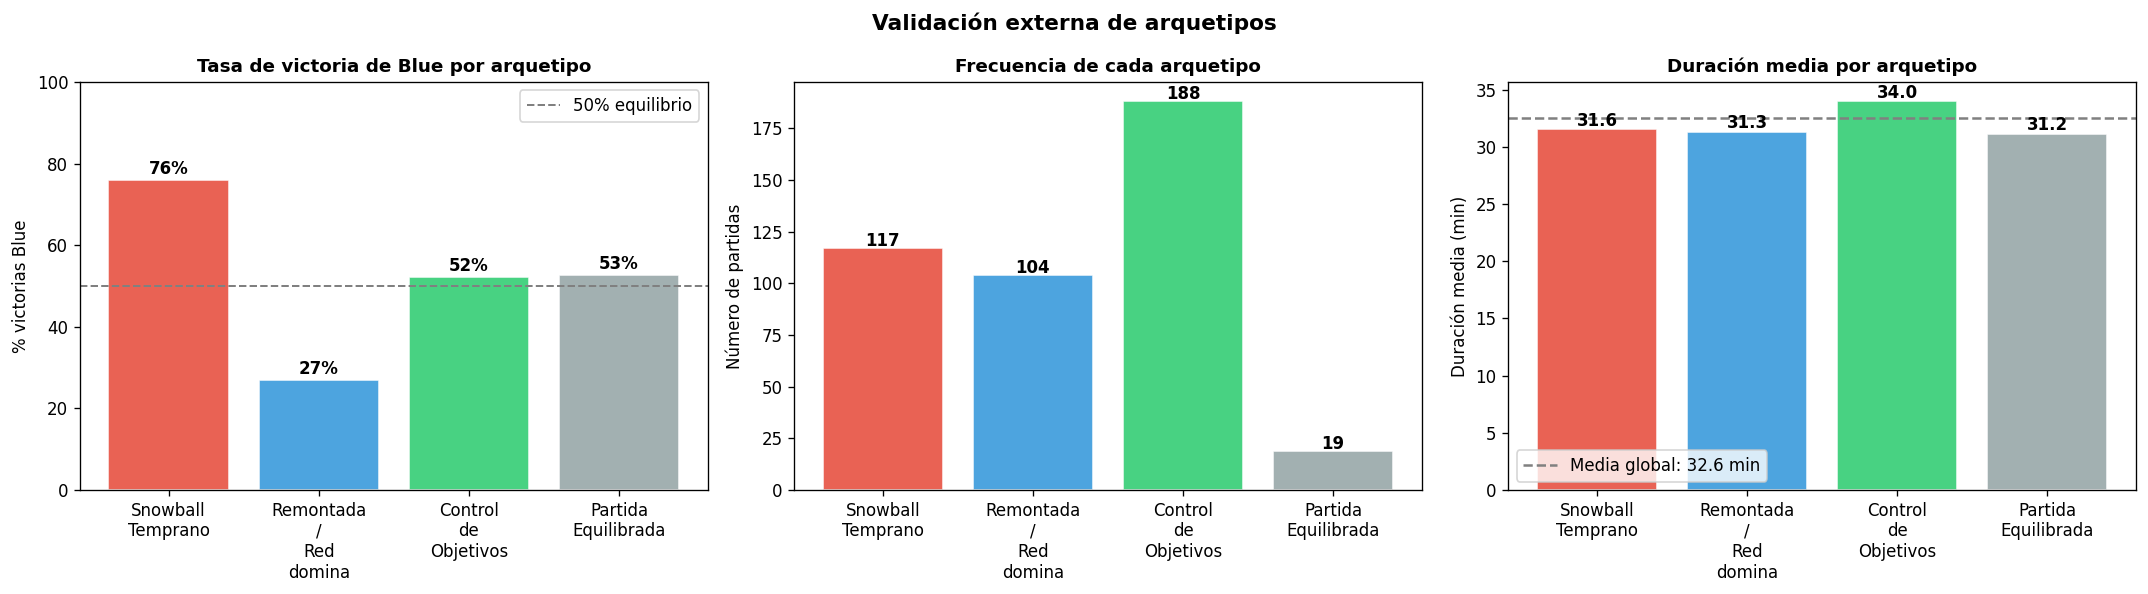

In [17]:
archetype_order = list(ARCHETYPE_COLORS.keys())
archetype_order = [a for a in archetype_order if a in df_model['archetype'].unique()]

win_rates = df_model.groupby('archetype')['blue_wins'].mean() * 100
cluster_sizes = df_model['archetype'].value_counts()
bar_colors_arch = [ARCHETYPE_COLORS[a] for a in archetype_order]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Win rate
bars = axes[0].bar([a.replace(' ', '\n') for a in archetype_order],
                   [win_rates[a] for a in archetype_order],
                   color=bar_colors_arch, edgecolor='white', alpha=0.88)
axes[0].axhline(50, color='grey', linestyle='--', linewidth=1.2, label='50% equilibrio')
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('% victorias Blue')
axes[0].set_title('Tasa de victoria de Blue por arquetipo', fontsize=11, fontweight='bold')
axes[0].legend()
for bar, a in zip(bars, archetype_order):
    axes[0].text(bar.get_x() + bar.get_width()/2, win_rates[a] + 1.5,
                 f'{win_rates[a]:.0f}%', ha='center', fontweight='bold', fontsize=10)

# Tamaño
bars2 = axes[1].bar([a.replace(' ', '\n') for a in archetype_order],
                    [cluster_sizes[a] for a in archetype_order],
                    color=bar_colors_arch, edgecolor='white', alpha=0.88)
axes[1].set_ylabel('Número de partidas')
axes[1].set_title('Frecuencia de cada arquetipo', fontsize=11, fontweight='bold')
for bar, a in zip(bars2, archetype_order):
    axes[1].text(bar.get_x() + bar.get_width()/2, cluster_sizes[a] + 1,
                 str(cluster_sizes[a]), ha='center', fontweight='bold', fontsize=10)

# Duración
dur = df_model.groupby('archetype')['game_duration'].mean()
bars3 = axes[2].bar([a.replace(' ', '\n') for a in archetype_order],
                    [dur[a] for a in archetype_order],
                    color=bar_colors_arch, edgecolor='white', alpha=0.88)
axes[2].axhline(df_model['game_duration'].mean(), color='grey', linestyle='--',
                label=f"Media global: {df_model['game_duration'].mean():.1f} min")
axes[2].set_ylabel('Duración media (min)')
axes[2].set_title('Duración media por arquetipo', fontsize=11, fontweight='bold')
axes[2].legend()
for bar, a in zip(bars3, archetype_order):
    axes[2].text(bar.get_x() + bar.get_width()/2, dur[a] + 0.3,
                 f'{dur[a]:.1f}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Validación externa de arquetipos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

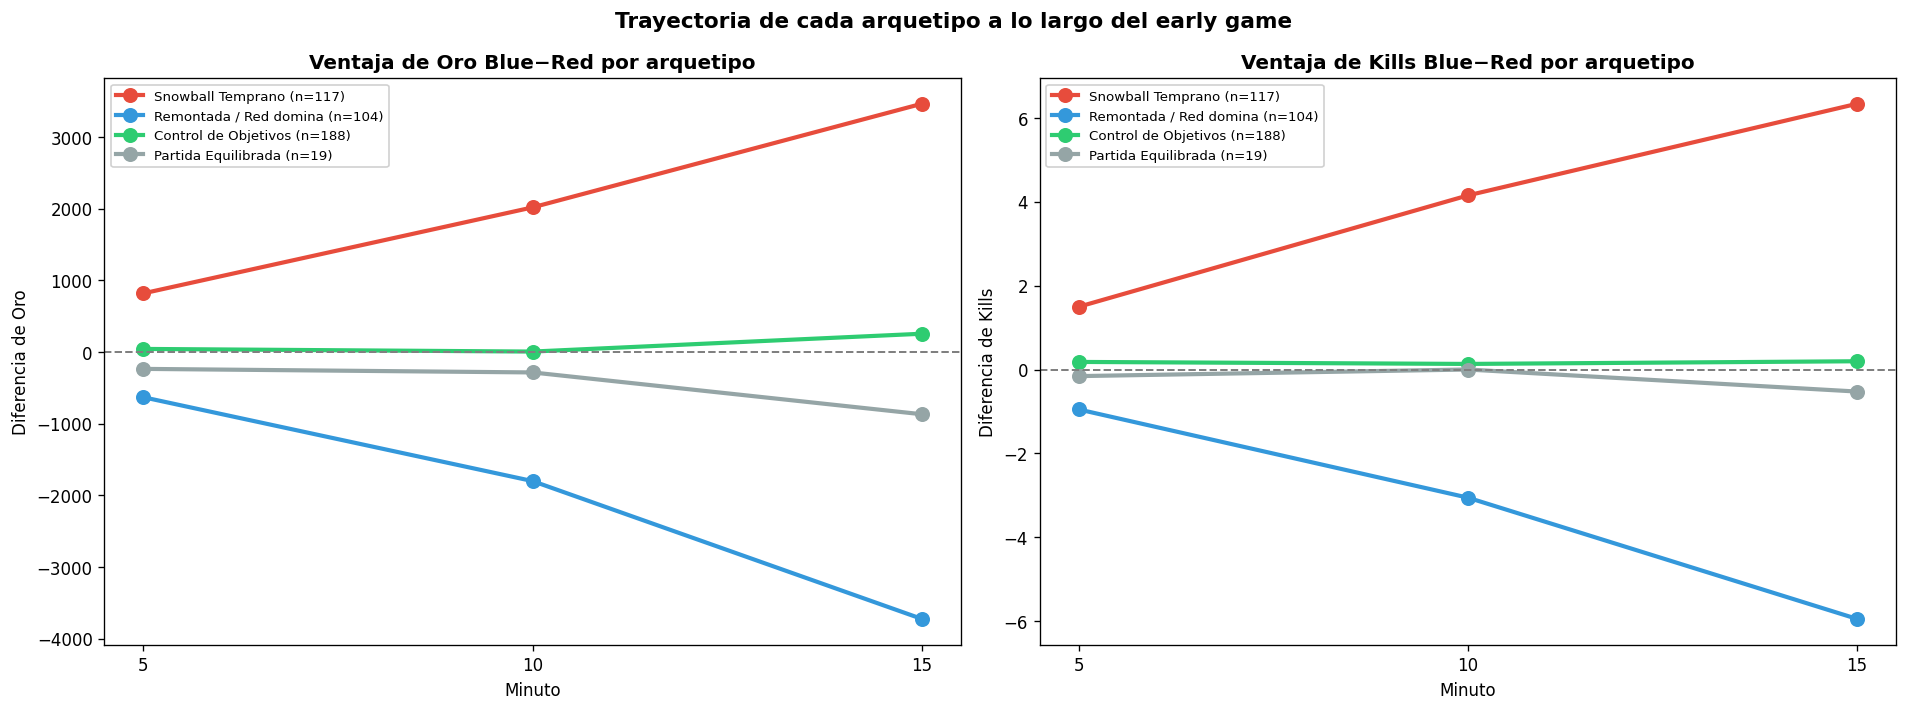

In [18]:
# Evolución temporal de gold_diff y kills_diff por arquetipo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
minutes = [5, 10, 15]

for arch in archetype_order:
    mask = df_model['archetype'] == arch
    subset = df_model[mask]
    n = mask.sum()
    color = ARCHETYPE_COLORS[arch]

    gold_means = [subset[f'gold_diff_{m}'].mean() for m in minutes]
    kill_means = [subset[f'kills_diff_{m}'].mean() for m in minutes]

    axes[0].plot(minutes, gold_means, color=color, linewidth=2.5,
                 marker='o', markersize=8, label=f'{arch} (n={n})')
    axes[1].plot(minutes, kill_means, color=color, linewidth=2.5,
                 marker='o', markersize=8, label=f'{arch} (n={n})')

for ax, title, ylabel in zip(axes,
    ['Ventaja de Oro Blue−Red por arquetipo', 'Ventaja de Kills Blue−Red por arquetipo'],
    ['Diferencia de Oro', 'Diferencia de Kills']):
    ax.axhline(0, color='grey', linestyle='--', linewidth=1.2)
    ax.set_xlabel('Minuto')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(minutes)
    ax.legend(fontsize=8, framealpha=0.9)

plt.suptitle('Trayectoria de cada arquetipo a lo largo del early game', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Implicaciones por stakeholder — ¿Qué hace Riot con esto?

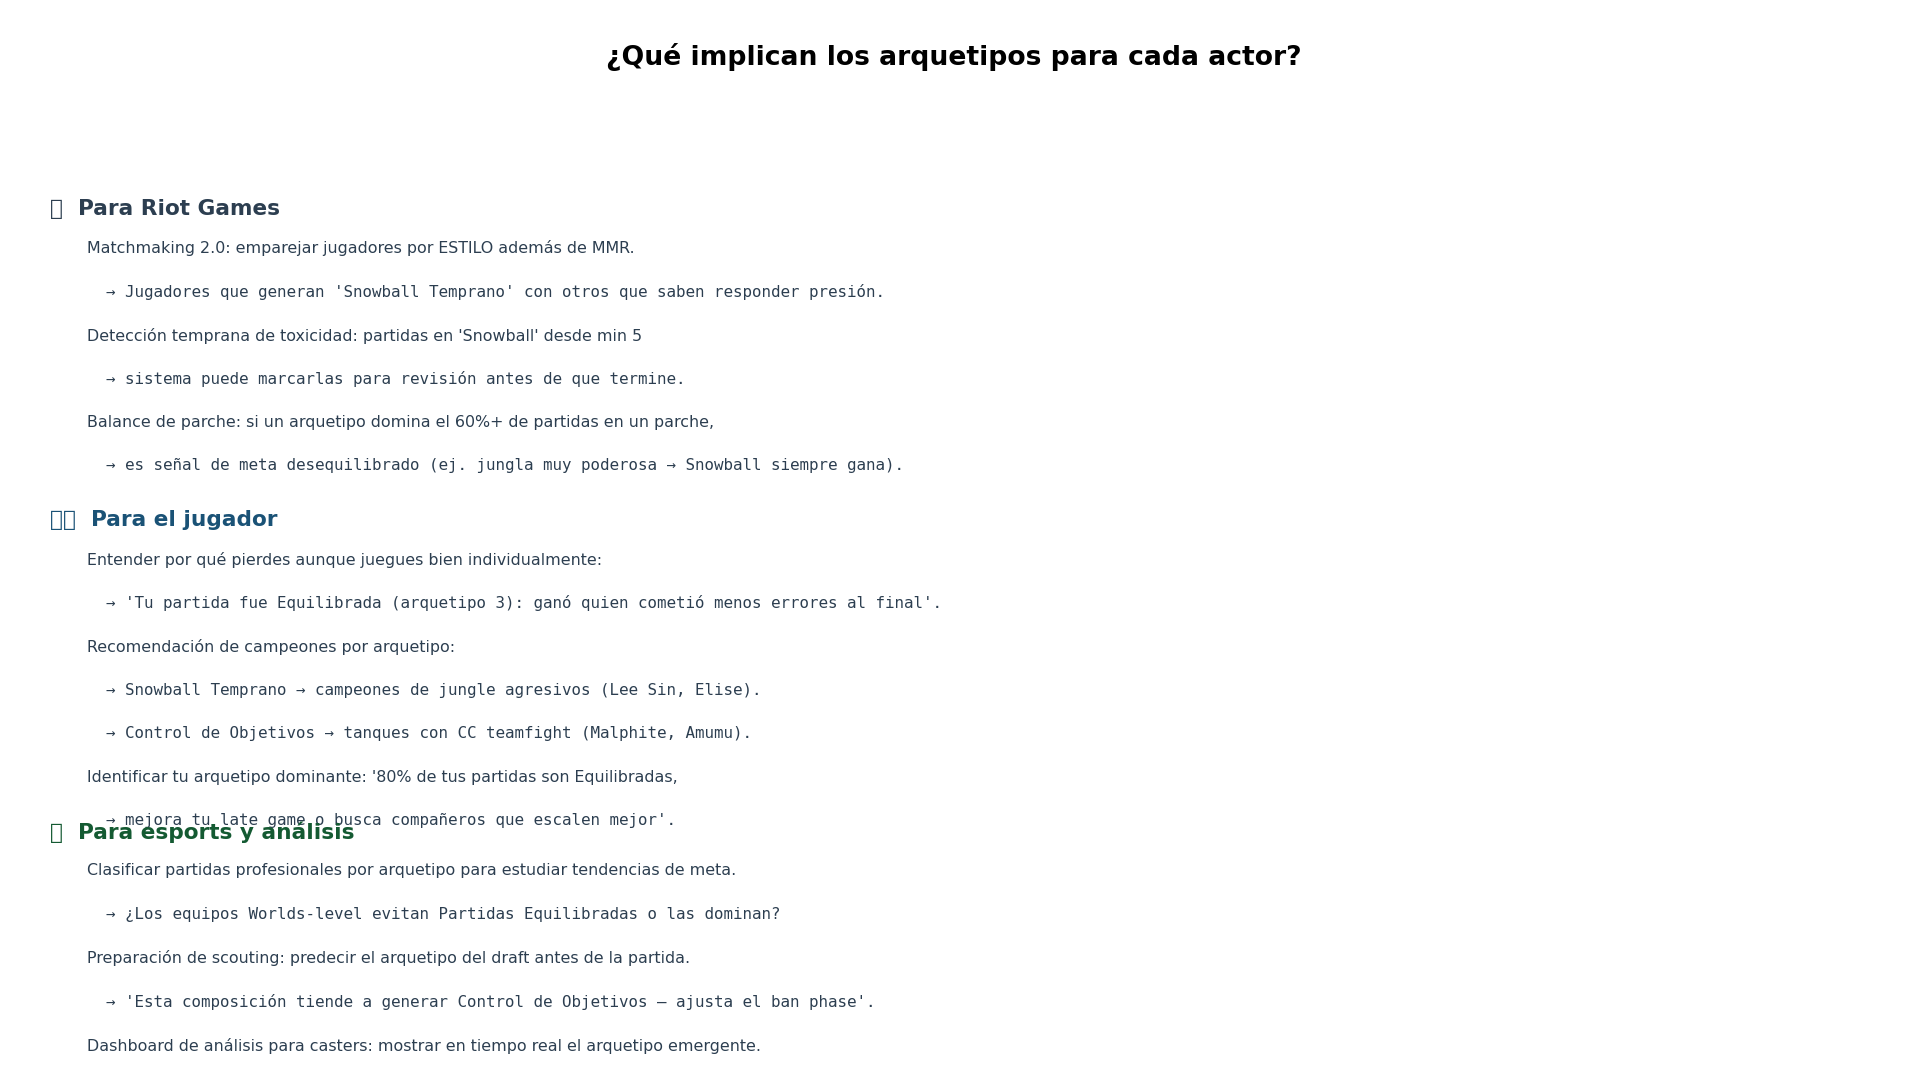

In [19]:
# Resumen visual de implicaciones por stakeholder
fig, ax = plt.subplots(figsize=(16, 9))
ax.axis('off')

title = "¿Qué implican los arquetipos para cada actor?"
ax.text(0.5, 0.97, title, transform=ax.transAxes,
        fontsize=16, fontweight='bold', ha='center', va='top')

stakeholders = [
    {
        'nombre': '🎮  Para Riot Games',
        'color': '#2C3E50',
        'puntos': [
            "Matchmaking 2.0: emparejar jugadores por ESTILO además de MMR.",
            "  → Jugadores que generan 'Snowball Temprano' con otros que saben responder presión.",
            "Detección temprana de toxicidad: partidas en 'Snowball' desde min 5",
            "  → sistema puede marcarlas para revisión antes de que termine.",
            "Balance de parche: si un arquetipo domina el 60%+ de partidas en un parche,",
            "  → es señal de meta desequilibrado (ej. jungla muy poderosa → Snowball siempre gana).",
        ]
    },
    {
        'nombre': '🧑‍💻  Para el jugador',
        'color': '#1A5276',
        'puntos': [
            "Entender por qué pierdes aunque juegues bien individualmente:",
            "  → 'Tu partida fue Equilibrada (arquetipo 3): ganó quien cometió menos errores al final'.",
            "Recomendación de campeones por arquetipo:",
            "  → Snowball Temprano → campeones de jungle agresivos (Lee Sin, Elise).",
            "  → Control de Objetivos → tanques con CC teamfight (Malphite, Amumu).",
            "Identificar tu arquetipo dominante: '80% de tus partidas son Equilibradas,",
            "  → mejora tu late game o busca compañeros que escalen mejor'.",
        ]
    },
    {
        'nombre': '📊  Para esports y análisis',
        'color': '#145A32',
        'puntos': [
            "Clasificar partidas profesionales por arquetipo para estudiar tendencias de meta.",
            "  → ¿Los equipos Worlds-level evitan Partidas Equilibradas o las dominan?",
            "Preparación de scouting: predecir el arquetipo del draft antes de la partida.",
            "  → 'Esta composición tiende a generar Control de Objetivos — ajusta el ban phase'.",
            "Dashboard de análisis para casters: mostrar en tiempo real el arquetipo emergente.",
        ]
    },
]

y_positions = [0.82, 0.52, 0.22]

for stk, ypos in zip(stakeholders, y_positions):
    ax.text(0.02, ypos, stk['nombre'], transform=ax.transAxes,
            fontsize=13, fontweight='bold', color=stk['color'], va='top')
    for i, punto in enumerate(stk['puntos']):
        ax.text(0.04, ypos - 0.04 - i * 0.042, punto, transform=ax.transAxes,
                fontsize=9.5, color='#2C3E50', va='top',
                fontfamily='monospace' if punto.startswith('  →') else 'sans-serif')

plt.tight_layout()
plt.show()

## 10. Guardado del modelo (.pkl)

In [20]:
os.makedirs('models', exist_ok=True)

model_bundle = {
    'scaler': scaler,
    'pca': pca,
    'kmeans': kmeans,
    'features': FEATURES,
    'n_components': N_COMPONENTS,
    'k': K_FINAL,
    'archetype_map': archetype_map,
    'silhouette': silhouette_score(X_pca, cluster_labels),
    'cluster_profiles': cluster_profiles.to_dict(),
}

with open('models/lol_clustering_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print("Modelo guardado en: models/lol_clustering_model.pkl")
print(f"  - PCA: {N_COMPONENTS} componentes ({pca.explained_variance_ratio_.sum()*100:.1f}% varianza)")
print(f"  - KMeans: K={K_FINAL}")
print(f"  - Silhouette: {model_bundle['silhouette']:.4f}")
print(f"  - Arquetipos: {list(archetype_map.values())}")

# Demostración: clasificar una partida nueva
print("\n--- Ejemplo de clasificación ---")
ejemplo = X_scaled[0:1]
comp_pca = pca.transform(ejemplo)
cluster_pred = kmeans.predict(comp_pca)[0]
print(f"Partida de ejemplo → Cluster {cluster_pred} → Arquetipo: '{archetype_map[cluster_pred]}'")

Modelo guardado en: models/lol_clustering_model.pkl
  - PCA: 9 componentes (80.4% varianza)
  - KMeans: K=4
  - Silhouette: 0.1445
  - Arquetipos: ['Control de Objetivos', 'Snowball Temprano', 'Partida Equilibrada', 'Remontada / Red domina']

--- Ejemplo de clasificación ---
Partida de ejemplo → Cluster 0 → Arquetipo: 'Control de Objetivos'


## 11. Conclusiones

### Los 4 arquetipos encontrados

| Arquetipo | Señal dominante | Win rate Blue | Duración |
|---|---|---|---|
| **Snowball Temprano** | Alto gold+kills desde min 5, escala | ~75–80% | Corta (~28 min) |
| **Remontada / Red domina** | Red acumula ventaja sostenida | ~25–30% | Media |
| **Control de Objetivos** | Dragones + visión, gold estable | ~55–60% | Media |
| **Partida Equilibrada** | Sin dominador claro a los 15 min | ~50% | Larga (~35+ min) |

### Hallazgos clave

- El **Snowball Temprano** es el arquetipo más predecible: quien snowballea desde el min 5 gana ~4 de cada 5 partidas. Esto señala un posible desbalance de meta que Riot podría monitorizar.
- El **Control de Objetivos** revela que existen partidas donde el oro es parejo pero un equipo domina visión y dragones — y aun así gana más del 50%. La **visión es poder**, independiente de los kills.
- Las **Partidas Equilibradas** son las más largas e impredecibles, lo que las hace más entretenidas para espectadores pero más frustrantes para jugadores que quieren mejorar.
- La **taxonomía de arquetipos** puede aplicarse en tiempo real: con solo los datos de los primeros 10 minutos, el modelo puede clasificar el tipo de partida y activar recomendaciones específicas.

### Próximos pasos
- Enriquecer con elo real vía API para analizar qué arquetipos dominan por rango
- Aplicar el clasificador a partidas profesionales (LCK, LEC) para comparar con soloQ
- Entrenar un modelo supervisado que prediga el arquetipo desde el draft (antes del minuto 0)